In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from datasets import EEGDenoiseDatasetContaminated, EEGDenoiseDataset
from pathlib import Path
from resunet import DeepDSP_UNetRes

import mne

In [3]:
from pathlib import Path

root = Path("current_study_data_raw")
digits = [
    p.name[1:]
    for p in root.iterdir()
    if p.is_dir() 
       and p.name.startswith("H") 
       and p.name[1:].isdigit()
]
print(digits)

['006', '012', '016', '017', '019', '022', '023', '024', '026', '028', '032', '034', '036', '038', '042', '043', '046', '047', '048', '049', '051', '053', '055', '057', '061', '063', '065', '067', '069', '079', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '115', '116', '117', '119', '120']


In [ ]:
from subject_segments import subject_segments

# your target keys (as integers)
target = {int(s) for s in [
    '6','12','16','17','19','22','23','24','26','28',
    '32','34','36','38','42','43','46','47','48','49',
    '51','53','55','57','61','63','65','67','69','79',
    '81','82','83','84','85','86','87','88','89','90',
    '91','92','93','94','95','96','97','98','99','100',
    '101','102','103','104','105','106','107','108','109','110',
    '111','112','115','116','117','119','120'
]}

# assume subject_segments is already defined
actual = set(subject_segments.keys())

missing = target - actual
extra   = actual - target

print("Missing keys:", sorted(missing))
print("Extra   keys:", sorted(extra))

Missing keys: []
Extra   keys: []


In [ ]:
raw = mne.io.read_raw_brainvision('current_study_data_raw/H120/H120_scan.vhdr', preload=False)

#chs = [
#    'Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2',
#   'F7','F8','T7','T8','P7','P8','FPz','Fz','Cz','Pz',
#    'POz','Oz','FT9','FT10',"TP9'","TP10'",
#    ]
#raw.pick(chs)
#raw.crop(tmin=654.76, tmax=1612.33)
#raw.crop(tmin=654.76, tmax=660.0)
raw.set_annotations(None)
raw.plot()
#raw.resample(512.)

Extracting parameters from current_study_data_raw/H120/H120_scan.vhdr...
Setting channel info structure...


C:\Users\np3106\AppData\Local\Temp\ipykernel_8564\355789424.py:1: RuntimeWarning: No coordinate information found for channels ['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision('current_study_data_raw/H120/H120_scan.vhdr', preload=False)
C:\Users\np3106\AppData\Local\Temp\ipykernel_8564\355789424.py:1: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision('current_study_data_raw/H120/H120_scan.vhdr', preload=False)


Channels marked as bad:
[np.str_('Pz')]
Channels marked as bad:
[np.str_('Pz')]


In [49]:
raw.info['ch_names'][0:26]
# 'Fp1',
#  'Fp2',
#  'F3',
#  'F4',
#  'C3',
#  'C4',
#  'P3',
#  'P4',
#  'O1',
#  'O2',
#  'F7',
#  'F8',
#  'T7',
#  'T8',
#  'P7',
#  'P8',
#  'FPz',
#  'Fz',
#  'Cz',
#  'Pz',
#  'POz',
#  'Oz',
#  'FT9',
#  'FT10',
#  "TP9'",

['Fp1',
 'Fp2',
 'F3',
 'F4',
 'C3',
 'C4',
 'P3',
 'P4',
 'O1',
 'O2',
 'F7',
 'F8',
 'T7',
 'T8',
 'P7',
 'P8',
 'Fpz',
 'Fz',
 'Cz',
 'Pz',
 'POz',
 'Oz',
 'FT9',
 'FT10',
 'M1',
 'M2']

In [5]:
raw_clean = mne.io.read_raw_brainvision('data_raw/016_scan.vhdr', preload=True)

chs = [
   'Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2',
  'F7','F8','T7','T8','P7','P8','FPz','Fz','Cz','Pz',
   'POz','Oz','FT9','FT10',"TP9'","TP10'",
   ]
raw_clean.pick(chs)
raw_clean.crop(tmin=490, tmax=652)
raw_clean.set_annotations(None)
raw_clean.resample(512.)

Extracting parameters from data_raw/016_scan.vhdr...
Setting channel info structure...


C:\Users\np3106\AppData\Local\Temp\ipykernel_6180\4143349409.py:1: RuntimeWarning: No coordinate information found for channels ['EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw_clean = mne.io.read_raw_brainvision('data_raw/016_scan.vhdr', preload=True)


Reading 0 ... 31733799  =      0.000 ...  6346.760 secs...


C:\Users\np3106\AppData\Local\Temp\ipykernel_6180\4143349409.py:1: RuntimeWarning: Not setting positions of 4 misc channels found in montage:
['EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw_clean = mne.io.read_raw_brainvision('data_raw/016_scan.vhdr', preload=True)


<RawBrainVision | 016_scan.eeg, 26 x 82944 (162.0 s), ~16.5 MiB, data loaded>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

CH_NAMES = [           # optional: if you want channel names
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2',
    'F7','F8','T7','T8','P7','P8','FPz','Fz','Cz','Pz',
    'POz','Oz','FT9','FT10',"TP9'","TP10'"
]

val_ds = EEGDenoiseDatasetContaminated(Path("data_segmented_3/16"))
val_dl = DataLoader(val_ds, batch_size=26, shuffle=False,
                    num_workers=2, pin_memory=True, drop_last=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepDSP_UNetRes(in_channels=3, out_channels=1).to(device)
model.load_state_dict(torch.load('best_model_eeg_3_TR_2_sensing.pt', map_location=torch.device('cpu')))
model.eval()

model2 = DeepDSP_UNetRes(in_channels=3, out_channels=1).to(device)
model2.load_state_dict(torch.load('best_model_eeg_3_TR_2_sensing.pt', map_location=torch.device('cpu')))
model2.eval()

full_cleaned = []
full_cleaned2 = []
full_contam = []

with torch.no_grad():
    for batch_idx, (x, noise_i, m, sd, ch) in enumerate(val_dl):
        #if batch_idx == 5:      # show first 10 batches
            #break
        x= x.to(device)
        m, sd = m.to(device),  sd.to(device)      # (B,) → scalars
        
        m  = m.view(-1, 1, 1)                     # (B,1,1)
        sd = sd.view(-1, 1, 1)                    # (B,1,1)
        
        cleaned = model(x)

        # pred_noise = model2(x)
        # cleaned_output = x[:, 0:1, :] - pred_noise # Normalized output
        # cleaned_output_raw = cleaned_output * sd + m # Denormalized outpu

        cleaned_output_raw = model2(x)

        cleaned_np = cleaned.cpu().numpy().squeeze(1)
        cleaned_np2 = cleaned_output_raw.cpu().numpy().squeeze(1)


        x_raw = x*sd + m
        contam_np = x_raw[:,0,:].cpu().numpy()

        full_cleaned.append(cleaned_np)
        full_cleaned2.append(cleaned_np2)
        full_contam.append(contam_np)

full_cleaned2 = np.concatenate(full_cleaned2, axis=1)
full_cleaned = np.concatenate(full_cleaned, axis=1)
full_contam = np.concatenate(full_contam, axis=1)

RuntimeError: Given groups=1, weight of size [32, 2, 9], expected input[26, 3, 192] to have 2 channels, but got 3 channels instead

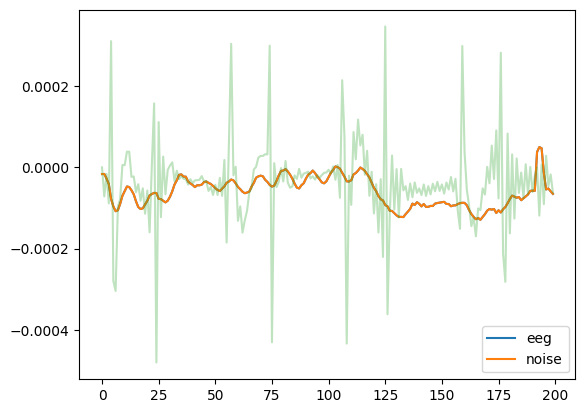

In [6]:
plt.plot(full_cleaned[20][0:200], label='eeg')
plt.plot(full_cleaned2[20][0:200], label='noise')
plt.plot(full_contam[20][0:200], alpha=0.3)
plt.legend()


In [10]:
def denoised(arr):
    assert arr.shape[1] >= full_cleaned2.shape[1], "Raw object too short for full_cleaned"

    # Replace only the first full_cleaned.shape[1] timepoints
    arr[:, :full_cleaned2.shape[1]] = full_cleaned2
    return arr

k = raw.copy()
k.apply_function(denoised, channel_wise=False)
k.plot()

def denoised(arr):
    assert arr.shape[1] >= full_cleaned.shape[1], "Raw object too short for full_cleaned"

    # Replace only the first full_cleaned.shape[1] timepoints
    arr[:, :full_cleaned.shape[1]] = full_cleaned
    return arr

l = raw.copy()
l.apply_function(denoised, channel_wise=False)
l.plot(title='b')

Using qt as 2D backend.


Channels marked as bad:
none
Channels marked as bad:
none


In [9]:
#raw.plot()
raw_clean.plot()

Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none


In [16]:
o = np.load('data_segmented_3_overlap/16/clean.npy')
o.shape

(11976, 26, 64)

In [11]:
val_ds = EEGDenoiseDataset(Path("data_segmented_1/16"))
val_dl = DataLoader(val_ds, batch_size=50, shuffle=False,
                    num_workers=2, pin_memory=True, drop_last=True)
for batch_idx, (x,y,clean_i, noise_i, m, sd, ch) in enumerate(val_dl):
        print('----')
        print(clean_i)
        print(noise_i)
print(clean_i)

c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


----
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1])
tensor([5035,  819,   67, 6761,  611, 4966, 2561,  137, 2712, 2628, 5939, 6709,
        7296,  541, 5076, 4932, 1793,  377, 1170, 3767,   62, 5637, 3126, 7276,
         444, 4919, 3207, 1010, 6034, 1792, 5678, 3304, 2352, 4019, 1358, 5602,
        1708, 1534, 1662, 4110, 5620, 2189, 4289, 2480, 4657, 7532, 2713, 6185,
        4762, 4183])
----
tensor([1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3])
tensor([ 396, 4070, 6261, 5153, 7383, 6985, 3880, 6768, 2759,  284,  358, 4992,
        2942, 2689, 6221, 3272, 7195, 6341, 2085, 3914, 3884, 1034, 5760,  250,
        3233, 6885, 1333, 5805, 4005,  328, 2372, 2298, 1162, 6514, 3197, 5060,
        5446, 3116, 4749, 6305, 6355, 6921, 1430, 3212, 270

In [6]:
o = np.load('data_segmented_3_overlap/16/clean.npy')
o.shape


(3987, 26, 192)

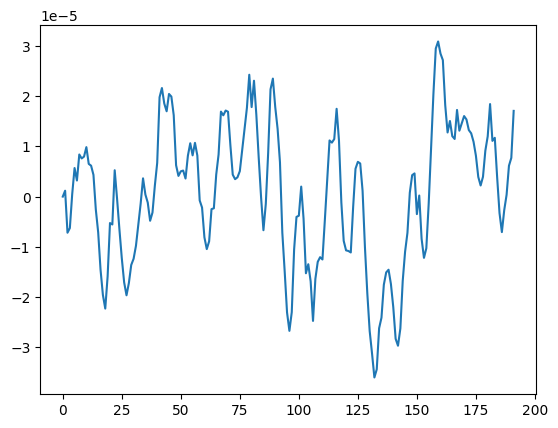

In [7]:
plt.plot(o[0,0])